In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [4]:
df = pd.read_csv('train.csv')

In [26]:
X = df.drop('label',axis = 1).values
y = df['label'].values

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [32]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [33]:
X_train_img = X_train.reshape(-1, 28,28)
X_test_img = X_test.reshape(-1, 28,28)

In [35]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [36]:
perc = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(10, activation='softmax'),
])

C:\Users\mohmm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
perc.compile(
    optimizer = 'sgd',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [41]:
hist_perc = perc.fit(
    X_train_img, y_train_cat, 
    validation_data = (X_test_img, y_test_cat),
    epochs = 5,
    batch_size = 32,
    verbose = 1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7837 - loss: 0.9486 - val_accuracy: 0.8564 - val_loss: 0.6013
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8674 - loss: 0.5290 - val_accuracy: 0.8746 - val_loss: 0.4853
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8819 - loss: 0.4532 - val_accuracy: 0.8835 - val_loss: 0.4381
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8899 - loss: 0.4161 - val_accuracy: 0.8880 - val_loss: 0.4104
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8938 - loss: 0.3928 - val_accuracy: 0.8923 - val_loss: 0.3932


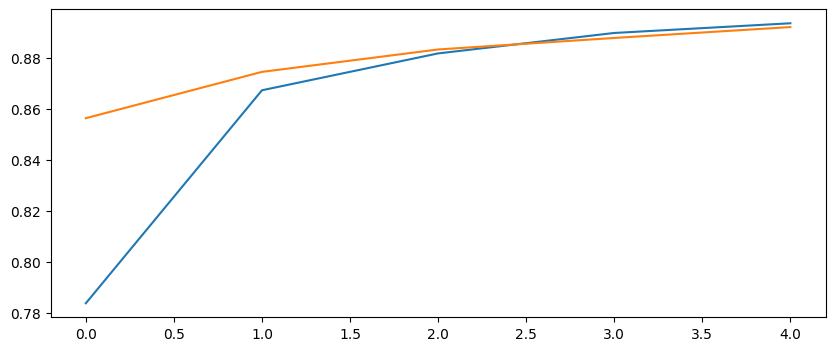

In [42]:
plt.figure(figsize = (10,4))
plt.plot(hist_perc.history['accuracy'], label = 'train_acc')
plt.plot(hist_perc.history['val_accuracy'], label = 'test_acc')

In [43]:
ann = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [44]:
ann.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [45]:
hist_ann = ann.fit(
    X_train_img, y_train_cat, 
    validation_data = (X_test_img, y_test_cat),
    epochs = 5,
    batch_size = 32,
    verbose = 1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9135 - loss: 0.2966 - val_accuracy: 0.9490 - val_loss: 0.1716
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9624 - loss: 0.1239 - val_accuracy: 0.9623 - val_loss: 0.1237
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9733 - loss: 0.0846 - val_accuracy: 0.9686 - val_loss: 0.1081
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9810 - loss: 0.0614 - val_accuracy: 0.9650 - val_loss: 0.1167
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9847 - loss: 0.0484 - val_accuracy: 0.9665 - val_loss: 0.1160


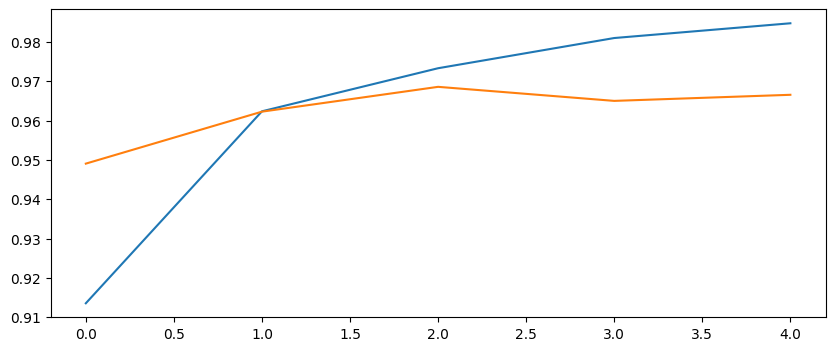

In [46]:
plt.figure(figsize = (10,4))
plt.plot(hist_ann.history['accuracy'], label = 'train_acc')
plt.plot(hist_ann.history['val_accuracy'], label = 'test_acc')

In [47]:
cnn = Sequential([
    Conv2D(
        32, 
        kernel_size=(3,3),
        activation = 'relu',
        input_shape = (28,28,1)
    ),
    MaxPooling2D(pool_size = (2,2)),
    Conv2D(
        64, 
        kernel_size=(3,3),
        activation = 'relu'
    ),
    MaxPooling2D(pool_size = (2,2)),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(10,activation = 'softmax')
])

C:\Users\mohmm\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
cnn.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [49]:
hist_cnn = cnn.fit(
    X_train_img, y_train_cat, 
    validation_data = (X_test_img, y_test_cat),
    epochs = 5,
    batch_size = 32,
    verbose = 1
)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9056 - loss: 0.3025 - val_accuracy: 0.9767 - val_loss: 0.0720
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9681 - loss: 0.1063 - val_accuracy: 0.9829 - val_loss: 0.0534
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9765 - loss: 0.0770 - val_accuracy: 0.9849 - val_loss: 0.0486
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9810 - loss: 0.0636 - val_accuracy: 0.9869 - val_loss: 0.0405
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9837 - loss: 0.0531 - val_accuracy: 0.9875 - val_loss: 0.0405


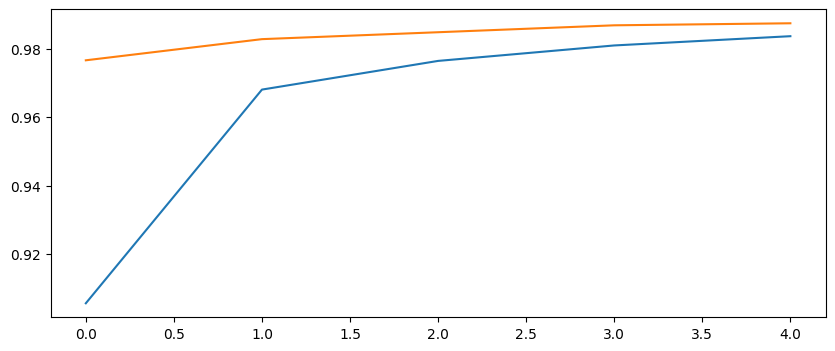

In [50]:
plt.figure(figsize = (10,4))
plt.plot(hist_cnn.history['accuracy'], label = 'train_acc')
plt.plot(hist_cnn.history['val_accuracy'], label = 'test_acc')

In [51]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


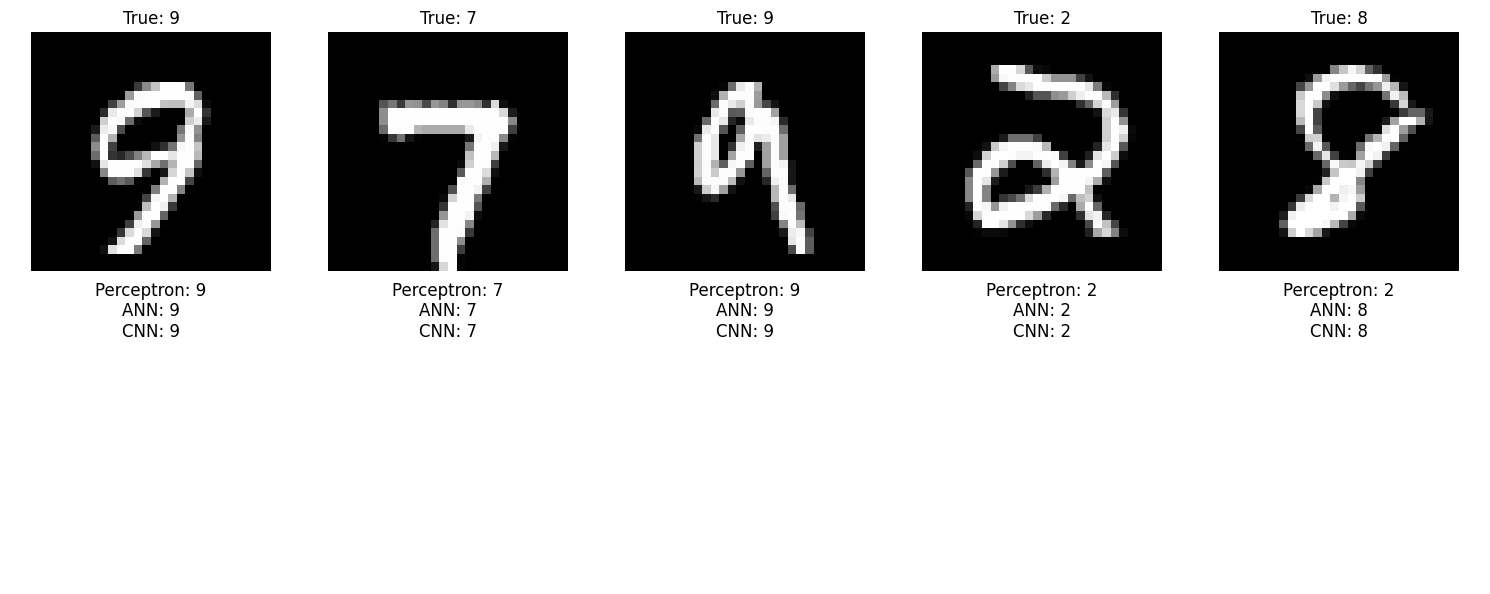

In [54]:
show_side_by_side([perc, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_img, y_test, 5)